# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Putting It All Together

In this notebook, you will implement everything required to create a strategy using the unsupervised technique of k-means on a stock from scratch.

The notebook is structured in the following manner:
1. [Read the Price Data and Calculate Features](#read)
1. [Select Appropriate Features](#features)
1. [Split the Data and Scale the Features](#split)
1. [Choose the Optimum Number of Clusters and Creating Clusters](#optimal)
1. [Analyse the Clusters and Generate Signals](#signal)

## Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

# Importing k-means model
from sklearn.cluster import KMeans

# Import min-max scaler
from sklearn.preprocessing import MinMaxScaler

# Quantra function to analyse the performance
import sys
sys.path.append("..")
from data_modules.unsupervised_learning_quantra import performance_analysis, calculate_features, stationary, get_number_of_clusters, hit_ratio_analysis, skewness_analysis, get_trades, get_analytics

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

<a id='read'></a>
## Read the Price Data and Calculate Features
We will use the 15-minute price data for Apple. The data is stored in the file `Apple Prices.csv` in the `data_modules` folder. 

We will make use of the custom function `calculate_features` to get the following features:
* **3 hours and 45 minutes return** or the 3.75 return (`ret375_hours`)
* **14-day** returns (`ret14_days`)
* **1-day** simple moving average (`SMA`)
* **1-day** volatility (`Volatility`)
* **14-day** volatility (`Volatility14`)
* **1-day** RSI (`RSI`)
* **1-day** ADX (`ADX`)
* **1-day** ATR (`ATR`)

Syntax:
```python
calculate_features(price_dataset)
```
* **price_dataset:** The dataframe containing the close price of the stock

Since we will be using the future returns to analyse the clusters, it is prudent to make that calculation at this step. We will calculate the 15-period future returns.

In [2]:
# Read CSV file
apple_prices = pd.read_csv(
    "../data_modules/Apple Prices.csv", index_col=0, parse_dates=True)

# Calculating 15-period future returns
time_prd = 15
apple_prices['fut_ret'] = apple_prices['close'].pct_change(
    time_prd).shift(-time_prd)

# Dropping rows with missing values
apple_prices.dropna(inplace=True)

# Calculate features
apple_prices = calculate_features(apple_prices)

apple_prices.head()

,close,high,low,open,volume,fut_ret,pct_change,ret375_hours,ret14_days,SMA,Volatility,Volatility14,RSI,ADX,ATR
date,,,,,,,,,,,,,,,
2016-01-25 10:30:00,100.61,100.65,100.57,100.65,63931.0,-0.000795,-0.003467,0.004794,-0.020351,100.336923,0.331258,0.470882,58.477396,18.946288,0.394694
2016-01-25 10:45:00,100.81,100.84,100.66,100.83,133243.0,-0.004464,0.001988,0.006791,-0.020977,100.388846,0.316151,0.470793,59.476186,18.875192,0.388360
2016-01-25 11:00:00,100.47,100.55,100.47,100.55,153464.0,-0.000597,-0.003373,0.001296,-0.027208,100.440000,0.316900,0.470840,57.049982,18.705719,0.386500
2016-01-25 11:15:00,100.60,100.72,100.60,100.71,88656.0,-0.004274,0.001294,-0.000298,-0.028113,100.482692,0.311382,0.470740,57.735560,18.610082,0.381250
2016-01-25 11:30:00,100.42,100.51,100.42,100.45,125687.0,-0.006174,-0.001789,-0.001293,-0.028162,100.531154,0.305410,0.470745,56.438291,18.419618,0.373509


<a id='features'></a>
## Select Appropriate Features
We will check the  features for stationarity and correlation amongst each other. 

To check the stationarity we will use the ADF test. We will make use of the function `stationary` we had created in the **Feature Selection** notebook for stationarity. The function output will indicate which features are non-stationary. We will drop these features.

In [3]:
# Features dataset
features = apple_prices.iloc[:, -8:]

"""
Check for stationarity
The below loop will not run in the browser. Download the notebook to your
local PC and comment out the code to see the output. The output will be as follows:

ret375_hours is stationary.
ret14_days is stationary.
SMA is not stationary.
Volatility is stationary.
Volatility14 is stationary.
RSI is stationary.
ADX is stationary.
ATR is stationary.
"""

# for col in features.columns:
#     if stationary(features[col]) == 'not stationary':
#         print('%s is not stationary.' % col)
#     else:
#         print('%s is stationary.' % col)

# Since the SMA is not stationary, we will drop the SMA from the `features` dataset and `apple_prices` dataset.

# Drop SMA from features dataset
features.drop(columns="SMA", inplace=True)

# Drop SMA from apple_prices dataset
apple_prices.drop(columns="SMA", inplace=True)

apple_prices.head()

,close,high,low,open,volume,fut_ret,pct_change,ret375_hours,ret14_days,Volatility,Volatility14,RSI,ADX,ATR
date,,,,,,,,,,,,,,
2016-01-25 10:30:00,100.61,100.65,100.57,100.65,63931.0,-0.000795,-0.003467,0.004794,-0.020351,0.331258,0.470882,58.477396,18.946288,0.394694
2016-01-25 10:45:00,100.81,100.84,100.66,100.83,133243.0,-0.004464,0.001988,0.006791,-0.020977,0.316151,0.470793,59.476186,18.875192,0.388360
2016-01-25 11:00:00,100.47,100.55,100.47,100.55,153464.0,-0.000597,-0.003373,0.001296,-0.027208,0.316900,0.470840,57.049982,18.705719,0.386500
2016-01-25 11:15:00,100.60,100.72,100.60,100.71,88656.0,-0.004274,0.001294,-0.000298,-0.028113,0.311382,0.470740,57.735560,18.610082,0.381250
2016-01-25 11:30:00,100.42,100.51,100.42,100.45,125687.0,-0.006174,-0.001789,-0.001293,-0.028162,0.305410,0.470745,56.438291,18.419618,0.373509


To check for correlation, we will take a threshold value of 70 and take action on a pair that gives a value above this.

In [4]:
# Correlation matrix for the features
corr_matrix = abs(features.corr())

# Unstack the correlation matrix
corr_matrix = corr_matrix.unstack()

# Get index pairs for which the correlation is greater than 0.7 but not equal to 1
pairs_above_threshold = corr_matrix[(
    corr_matrix > 0.7) & (corr_matrix != 1.0)].index

# Print pairs above the threshold
print(pairs_above_threshold)

MultiIndex([(  'Volatility',          'ATR'),
            ('Volatility14',          'ATR'),
            (         'ATR',   'Volatility'),
            (         'ATR', 'Volatility14')],
           )


You can see that `ATR` is correlated with both `Volatility` and `Volatility14`. Therefore, we will remove `ATR` from our features. You can also remove `Volatility` and `Volatility14`.

In [5]:
# Drop ATR from features dataset
features.drop(columns="ATR", inplace=True)

# Drop ATR from apple_prices dataset
apple_prices.drop(columns="ATR", inplace=True)

<a id='split'></a>
## Split the Data and Scale the Features
We will split the data into training and testing datasets. 75% of the data will belong to training and the balance to testing. Once we find the clusters using the training data set, we will check their effectiveness using the test data set.

We will scale the features using the min-max scaler technique.

In [6]:
# Split and get features_train and features_test
split = int(len(features) * 0.75)
features_train, features_test = features[:split], features[split:]

# Slicing apple_prices to get apple_prices_train and apple_prices_test
apple_prices_train, apple_prices_test = apple_prices[:split], apple_prices[split:]

# Fit MinMaxScaler on features_train
scaler = MinMaxScaler().fit(features_train)

# Scale features_train using the `scaler` initialised above
features_train = pd.DataFrame(scaler.transform(
    features_train), columns=features.columns, index=features_train.index)

# Scale features_test using the `scaler` initialised above
features_test = pd.DataFrame(scaler.transform(
    features_test), columns=features.columns, index=features_test.index)

print("Training data set shape          : ", features_train.shape)
print("Test data set shape              : ", features_test.shape)

print("Apple prices train data set shape: ", apple_prices_train.shape)
print("Apple prices test data set shape : ", apple_prices_test.shape)

Training data set shape          :  (20654, 6)
Test data set shape              :  (6885, 6)
Apple prices train data set shape:  (20654, 13)
Apple prices test data set shape :  (6885, 13)


<a id='optimal'></a>
## Choose the Optimum Number of Clusters and Creating Clusters
We will choose the optimal number of clusters using the elbow curve method. In the notebook on **Choosing the Optimal Number of Clusters**, we had created a function `get_number_of_clusters`. We will utilise the same for this task.

Next, we will fit the k-means model with the optimal number of clusters, using the `features_train` dataset. After that, we will check what cluster number an observation belongs to in the test dataset using the `predict` method.

The below cell will take some time to run. The `get_number_of_clusters` function is computationally intensive. Please wait a while.

In [7]:
# Getting optimal number of clusters
num_clusters = get_number_of_clusters(
    features_train, threshold=4, max_range=30)

# Initialise the model with num_clusters
model = KMeans(n_clusters=num_clusters, random_state=40)

# Fit the model on features_train
model.fit(features_train)

# Getting the cluster for each observation in the train data set
apple_prices_train["cluster"] = model.predict(features_train)

# Getting the cluster for each observation in the test data set
apple_prices_test["cluster"] = model.predict(features_test)

<a id='signal'></a>
## Analyse the Clusters and Generate Signals
We will analyse the clusters based on hit ratio and skewness as done in previous notebooks. We will use two different functions, `hit_ratio_analysis` and `skewness_analysis`. The function takes the following arguments:
* **training_dataset:** The training data set of the stock prices along with the cluster number for each observation.
* **testing_dataset:** The testing data set of the stock prices along with the cluster number for each observation.

The function will add a column `direction` to the `testing_dataset` based on the analysis performed on hit ratio or skewness.

In [8]:
# Running the hit ratio analysis
hit_ratio_analysis(apple_prices_train, apple_prices_test)

# Running the skewness analysis
skewness_analysis(apple_prices_train, apple_prices_test)

apple_prices_test.head()

,close,high,low,open,volume,fut_ret,pct_change,ret375_hours,ret14_days,Volatility,Volatility14,RSI,ADX,cluster,direction_hit_ratio,direction_skewness
date,,,,,,,,,,,,,,,,
2019-04-10 11:00:00,199.54,199.63,199.54,199.54,49063.0,0.000651,0.000652,-0.002250,0.024753,0.205856,0.251258,49.381530,20.758366,0,0,0
2019-04-10 11:15:00,199.50,199.49,199.40,199.42,21562.0,0.002155,-0.000200,-0.000851,0.026287,0.200467,0.251090,49.116434,20.340828,0,0,0
2019-04-10 11:30:00,199.38,199.48,199.37,199.49,27096.0,0.004915,-0.000602,-0.000050,0.024142,0.198445,0.251005,48.307325,19.953605,0,0,0
2019-04-10 11:45:00,199.35,199.34,199.26,199.25,29503.0,0.006872,-0.000150,-0.001853,0.023147,0.198571,0.250976,48.101305,19.634578,0,0,0
2019-04-10 12:00:00,199.32,199.36,199.30,199.34,14003.0,0.006673,-0.000150,-0.001503,0.023729,0.197963,0.250945,47.888900,19.315315,0,0,0


We have got two additional columns, `direction_hit_ratio` and `direction_skewness`. Let us calculate the strategy returns based on the direction and plot them using the `performance_analysis` function.

### Calculate and Plot the Strategy Returns

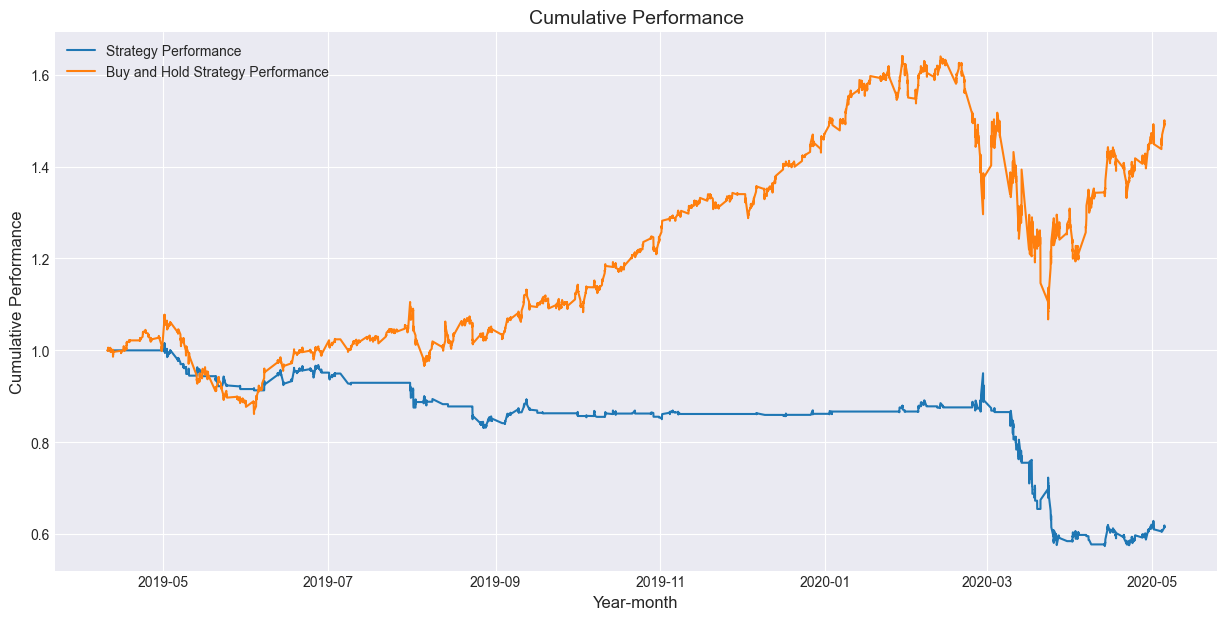

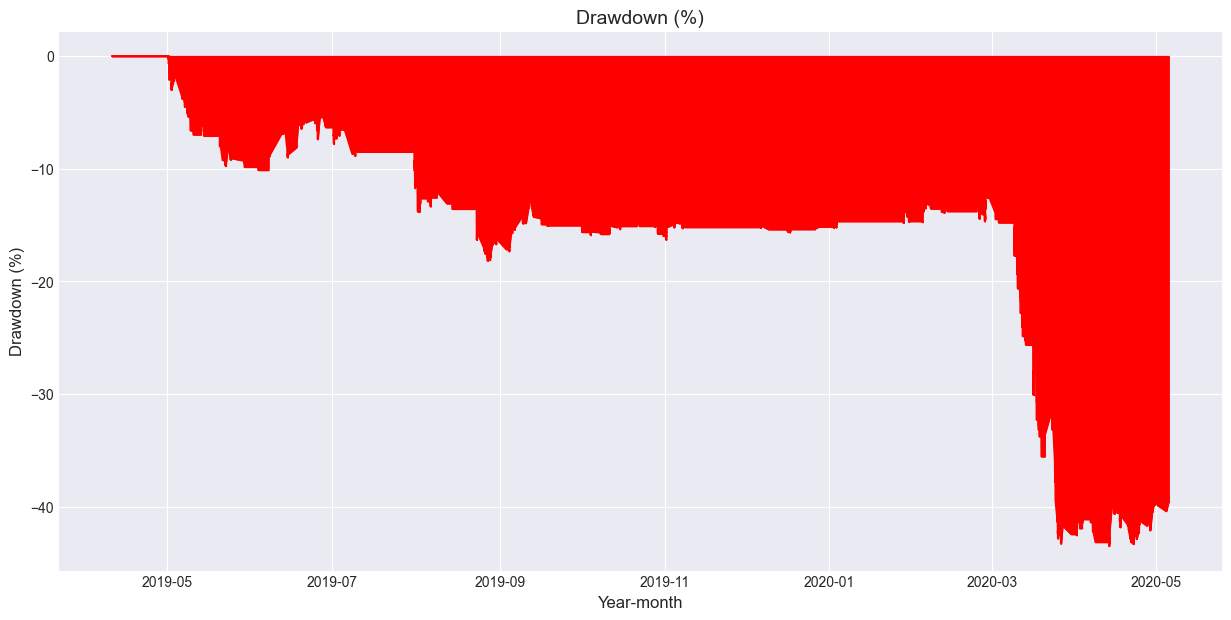

Total returns: -38.24%
Annualised returns (CAGR): -36.79%
Maximum drawdown (MDD): -43.48%
Return-to-MDD ratio: 0.85


In [9]:
# Calculate the buy and hold returns
benchmark_returns = (
    1 + apple_prices_test["close"].pct_change()).cumprod().dropna()

# Calculate the strategy returns based on hit ratio analysis
apple_prices_test['returns'] = apple_prices_test["close"].pct_change(
) * apple_prices_test["direction_hit_ratio"].shift(1)

# Calculate the cumulative returns
apple_prices_test['cumulative_returns_hit_ratio'] = (
    1 + apple_prices_test['returns']).cumprod()

# Drop rows with missing values
apple_prices_test.dropna(inplace=True)

# Call the performance analysis function
performance_analysis(
    apple_prices_test['cumulative_returns_hit_ratio'], benchmark_returns)

As we had seen earlier, the strategy based on hit ratio performs very poorly. Let us also look at the trade-wise analytics for strategy based on hit ratio.

In [10]:
# Trade log
trade_log = get_trades(apple_prices_test, "close", "direction_hit_ratio")

# Analytics
analytics = get_analytics(trade_log)

analytics

,Strategy
Number of long trades,73.00
Number of short trades,46.00
Total number of trades,119.00
Gross profit,87.45
Gross loss,-194.79
Net profit,-107.34
Number of winners,36.00
Number of losers,83.00
Winning percentage,30.25
Losing percentage,69.75


Let us plot the returns for analysis based on skewness and also do a trade-wise analysis.

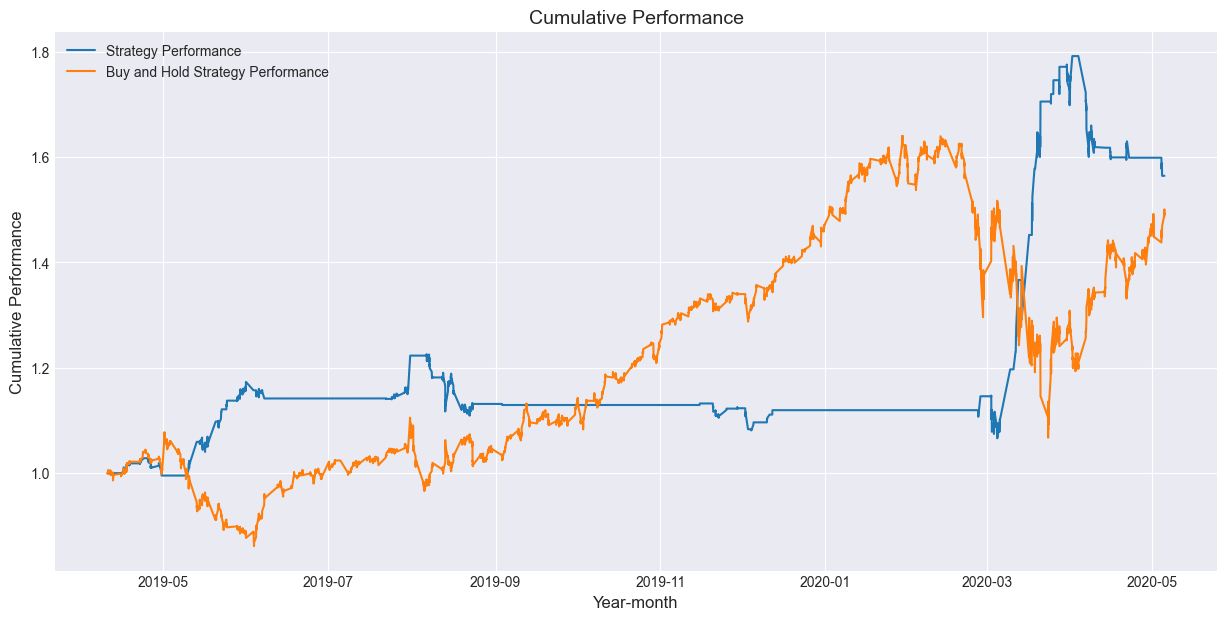

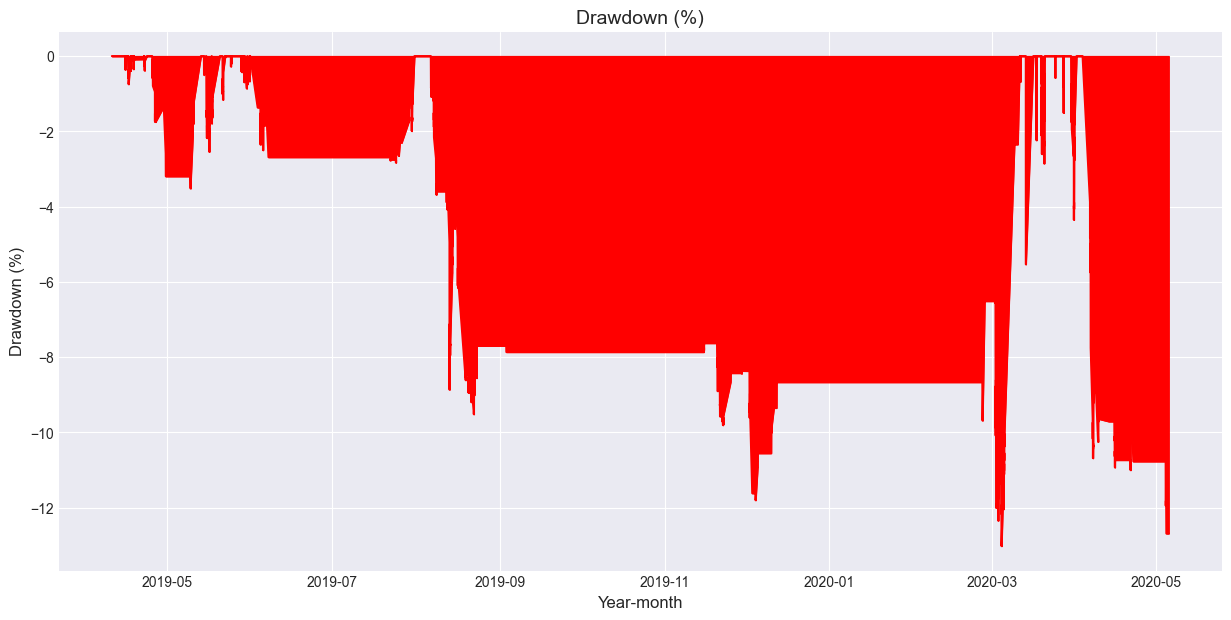

Total returns: 56.46%
Annualised returns (CAGR): 53.12%
Maximum drawdown (MDD): -13.02%
Return-to-MDD ratio: 4.08


,Strategy
Number of long trades,31.00
Number of short trades,56.00
Total number of trades,87.00
Gross profit,223.07
Gross loss,-100.20
Net profit,122.87
Number of winners,63.00
Number of losers,24.00
Winning percentage,72.41
Losing percentage,27.59


In [11]:
# Calculate the strategy returns based on hit ratio analysis
apple_prices_test['returns'] = apple_prices_test["close"].pct_change(
) * apple_prices_test["direction_skewness"].shift(1)

# Calculate the cumulative returns
apple_prices_test['cumulative_returns_skewness'] = (
    1 + apple_prices_test['returns']).cumprod()

# Drop rows with missing values
apple_prices_test.dropna(inplace=True)

# Call the performance analysis function
performance_analysis(
    apple_prices_test['cumulative_returns_skewness'], benchmark_returns)

# Trade log
trade_log = get_trades(apple_prices_test, "close", "direction_skewness")

# Analytics
analytics = get_analytics(trade_log)

analytics

Compared to the performance of hit ratio, trades based on skewness analysis performed extremely well.

You now have the tools to use k-means clustering and generate trading signals on any asset class. <br><br>